In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.colors import to_rgba

from bayes_network import BayesNetwork
from bootstrap import NetworkBootstrap, bayes_network_edge_fn
from resources.config_experiment import *

DATA_PATH = "../data/grinding_normalized.csv"
RANDOM_STATE = 42

## Data reading

In [3]:
df_model = pd.read_csv(DATA_PATH)
df_model.head()

,ids,doi,Type of Synthesis,Formula,API,Coformer,Part of Ratio API,Part of Ratio Coformer,Amount of API,Amount of Coformer,...,Frequency Unit,Mixing Time,Mixing Time Unit,Mixing Temperature,Mixing Temperature Unit,Drying Time,Drying Time Unit,Drying Temperature,Drying Temperature Unit,Temperature of Drying (numeric)
0,id0007,10.3390/pharmaceutics13040546,liquid-assisted grinding,MTZ-EG,metronidazole,ethyl gallate,"[0.5, 1.5)","[0.5, 1.5)","[21.2, 33.3)","[21.1, 33.8)",...,hz,"[30.0, 40.0)",min,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
1,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
2,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[1.5, 2.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
3,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[1.5, 2.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
4,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,PA-HQ,piracetam,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED


In [7]:
def plot_graph(graph, node_color="#ffb703", random_state_addition=989, title=''):
    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE+random_state_addition, k=0.9, method='energy')

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.7, arrowsize=15,
                            connectionstyle="arc3,rad=0.05")
    ax.set_title(title)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()

## Bayes Network with BIC

In [5]:
bn_bic = BayesNetwork(max_parents=1, criterion="bic", max_iterations=50).fit(df_model, VARIABLE_COLUMNS)

In [6]:
bn_bic.edge_table()

,parent,child
0,Type of Synthesis,Solvent
1,Type of Synthesis,Part of Ratio Coformer
2,Mixing Apparatus,Mixing Time
3,Part of Ratio Coformer,Part of Ratio API
4,Amount of API,Amount of Coformer
5,Amount of Solvent,Type of Synthesis
6,Amount of Solvent,Mixing Frequency
7,Mixing Frequency,Mixing Apparatus
8,Mixing Frequency,Amount of API
9,Mixing Frequency,Mixing Temperature


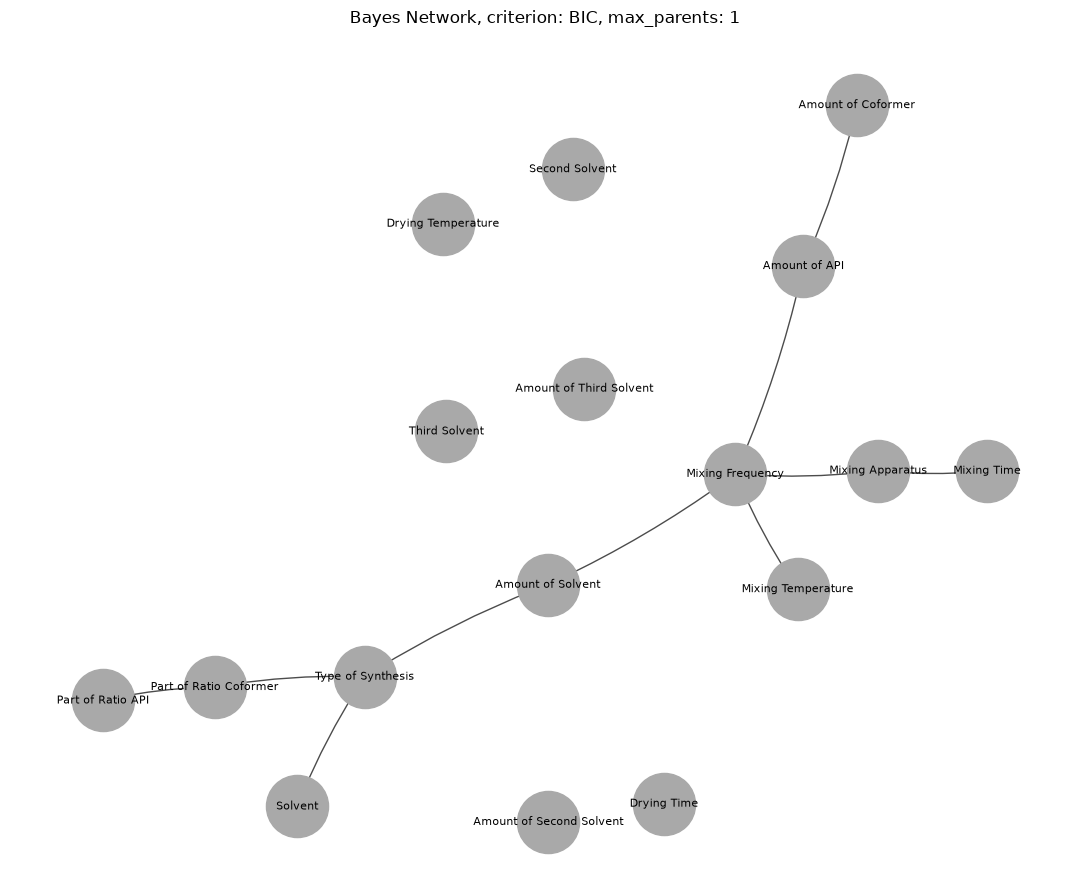

In [7]:
plot_graph(bn_bic.graph, node_color="darkgray", title="Bayes Network, criterion: BIC, max_parents: 1")

## Bayes Network with AIC

In [8]:
bn_aic = BayesNetwork(max_parents=1, criterion="aic", max_iterations=50).fit(df_model, VARIABLE_COLUMNS)

In [9]:
bn_aic.edge_table()

,parent,child
0,Type of Synthesis,Solvent
1,Type of Synthesis,Second Solvent
2,Solvent,Amount of Solvent
3,Second Solvent,Amount of Second Solvent
4,Second Solvent,Third Solvent
5,Mixing Apparatus,Mixing Time
6,Part of Ratio Coformer,Part of Ratio API
7,Amount of API,Part of Ratio Coformer
8,Amount of Coformer,Amount of API
9,Amount of Solvent,Mixing Frequency


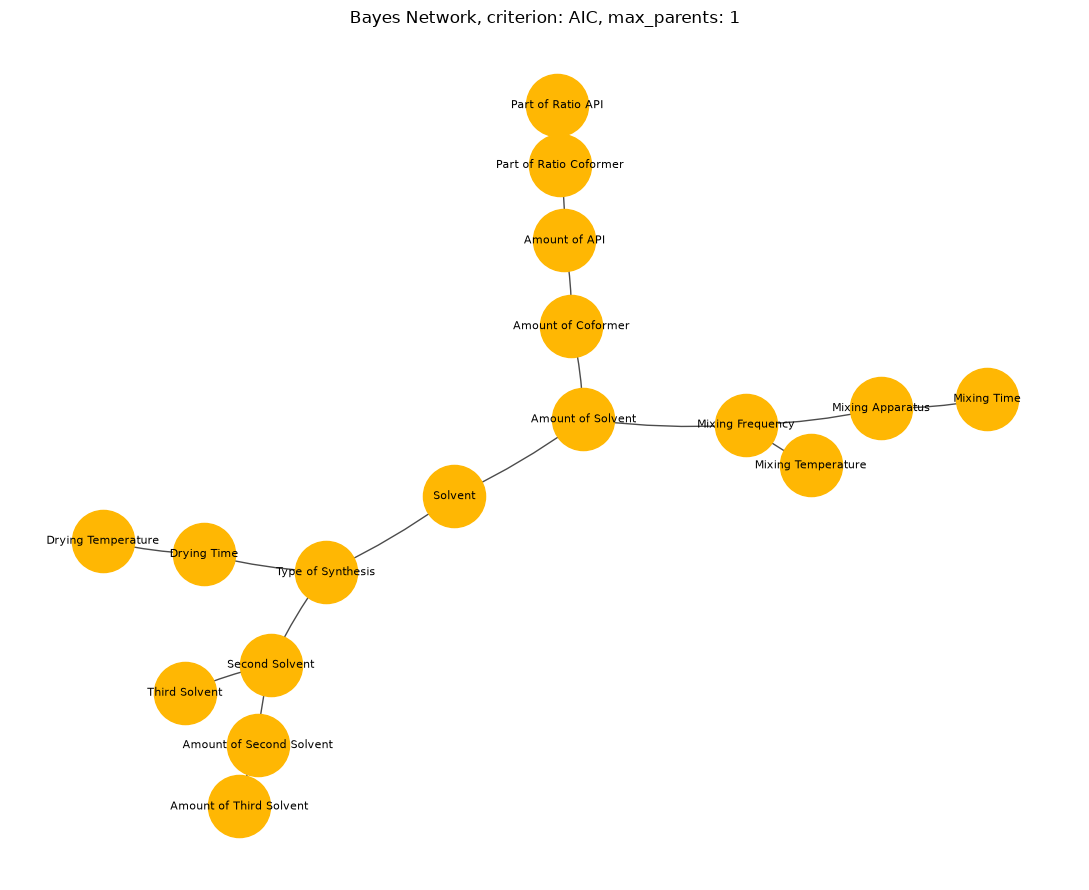

In [10]:
plot_graph(bn_aic.graph, title="Bayes Network, criterion: AIC, max_parents: 1")

## Bootstrap

In [4]:
N_ITERATIONS_AIC = 50

aic_fit_fn = bayes_network_edge_fn(VARIABLE_COLUMNS, criterion='aic', max_parents=1, max_iterations=50)
aic_edges_table = NetworkBootstrap(aic_fit_fn, n_iterations=N_ITERATIONS_AIC).run(df_model)

100%|██████████| 50/50 [28:22<00:00, 34.05s/it]


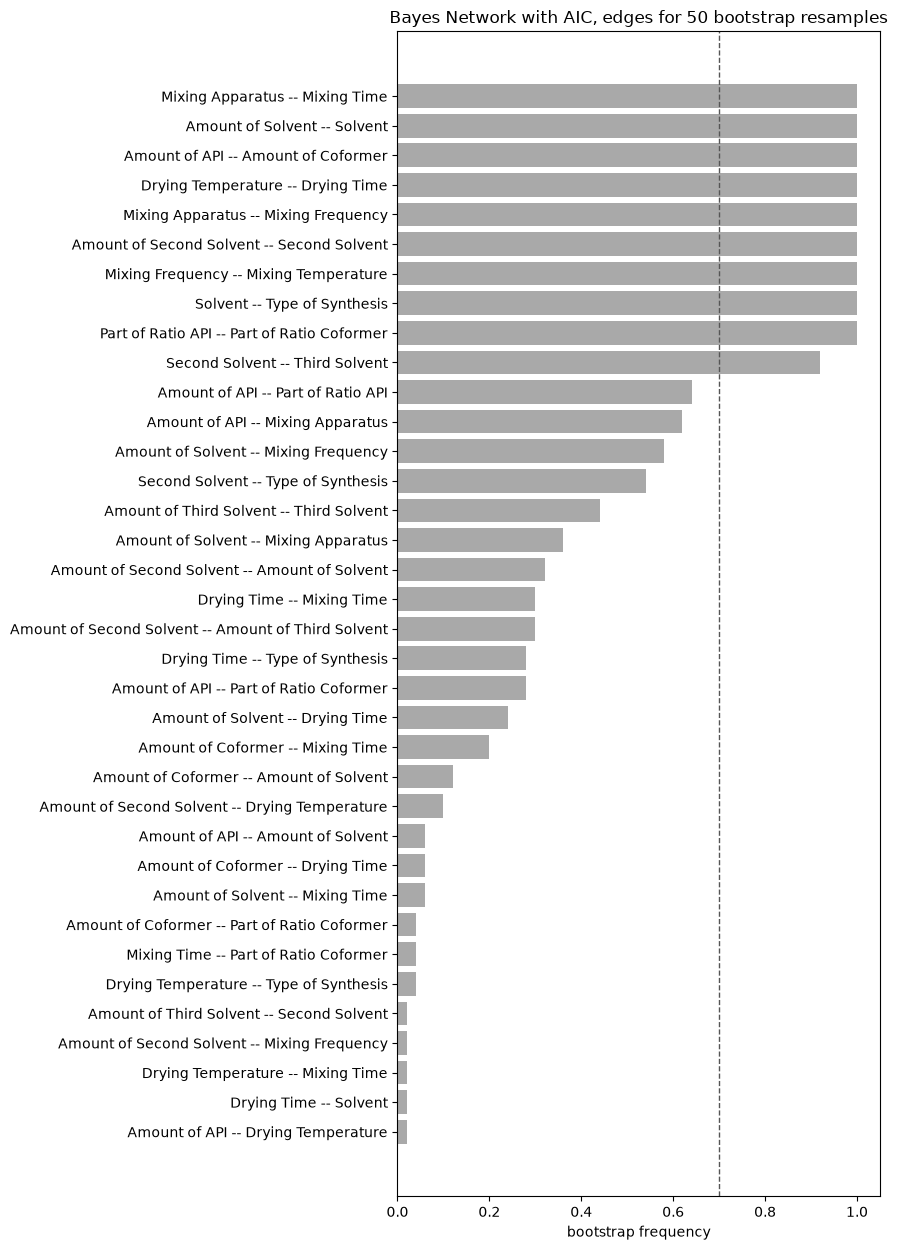

In [ ]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(aic_edges_table))))
labels = aic_edges_table["V1"] + " -- " + aic_edges_table["V2"]

ax.barh(labels, aic_edges_table["frequency"], color="darkgray")
ax.invert_yaxis()
ax.set_xlabel("bootstrap frequency")
ax.set_title(f"Bayes Network with AIC, edges for {N_ITERATIONS_AIC} bootstrap resamples")
ax.axvline(0.7, color="#555", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [126]:
def plot_bootstrap_graph(edges_table, node_color="#ffb703", edge_color="#264653",
                          min_frequency=0.0, random_state_addition=989, title=""):
    graph = nx.Graph()
    for _, row in edges_table.iterrows():
        if row["frequency"] >= min_frequency:
            graph.add_edge(row["V1"], row["V2"], weight=row["frequency"])

    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE + random_state_addition, k=50000, weight="weight", method="energy")

    weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    widths = [1 + 6 * w for w in weights]
    colors = [to_rgba(edge_color, alpha=0.15 + 0.8 * w) for w in weights]

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=widths, edge_color=colors)
    ax.set_title(title)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

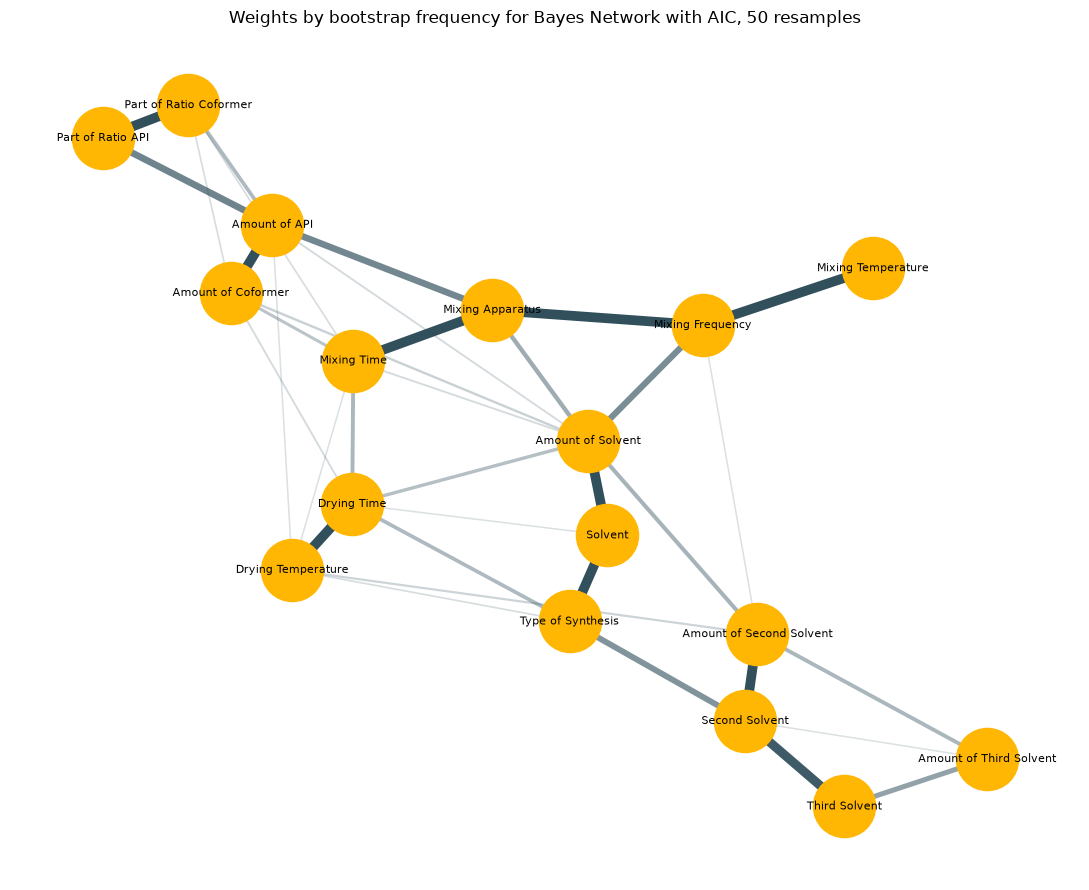

In [127]:
plot_bootstrap_graph(
    aic_edges_table, random_state_addition=70,
    title=f"Weights by bootstrap frequency for Bayes Network with AIC, {N_ITERATIONS_AIC} resamples",
)

In [ ]:
aic_fit_fn_directed = bayes_network_edge_fn(
    VARIABLE_COLUMNS, 
    criterion='aic',
    max_parents=1,
    max_iterations=50,
    directed=True
)

aic_edges_table_directed = NetworkBootstrap(aic_fit_fn_directed, n_iterations=N_ITERATIONS_AIC, directed=True).run(df_model)

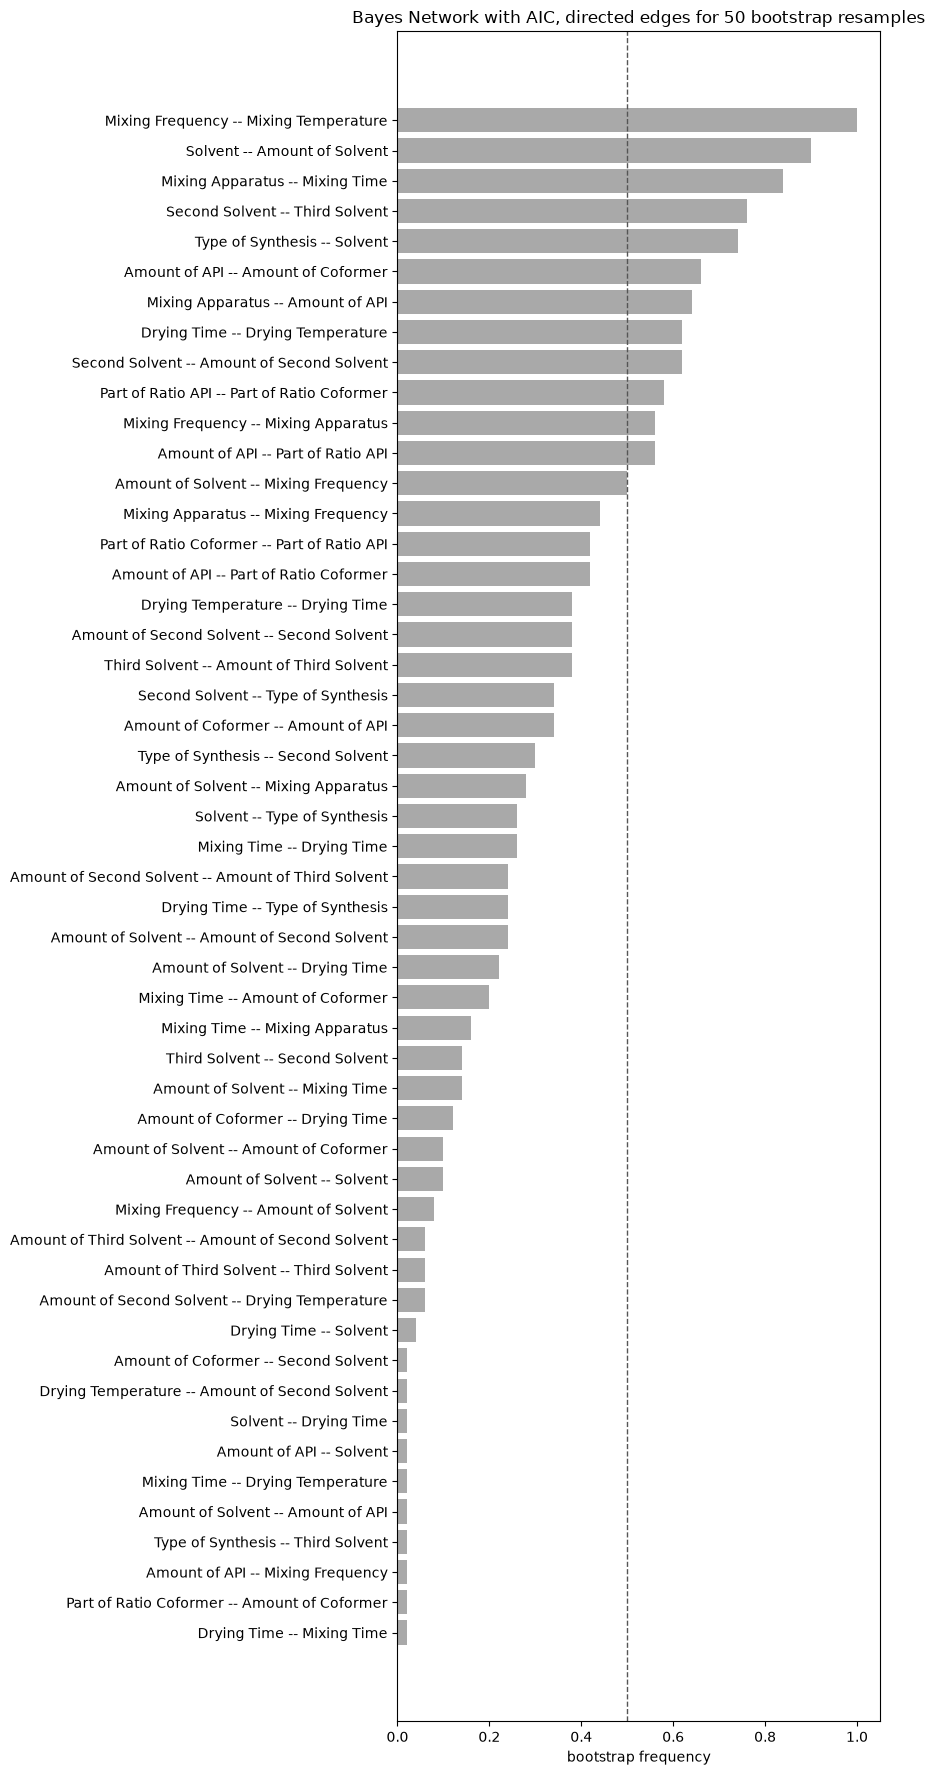

In [11]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(aic_edges_table_directed))))
labels = aic_edges_table_directed["parent"] + " -- " + aic_edges_table_directed["child"]

ax.barh(labels, aic_edges_table_directed["frequency"], color="darkgray")
ax.invert_yaxis()
ax.set_xlabel("bootstrap frequency")
ax.set_title(f"Bayes Network with AIC, directed edges for {N_ITERATIONS_AIC} bootstrap resamples")
ax.axvline(0.5, color="#555", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [87]:
def plot_bootstrap_digraph(edges_table, node_color="#ffb703", edge_color="#264653",
                            min_frequency=0.0, random_state_addition=989, title=""):
    graph = nx.DiGraph()
    for _, row in edges_table.iterrows():
        if row["frequency"] >= min_frequency:
            graph.add_edge(row["parent"], row["child"], weight=row["frequency"])

    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE + random_state_addition, k=50000, weight="weight", method="energy")
    
    weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    widths = [1 + 5 * w for w in weights]
    colors = [to_rgba(edge_color, alpha=0.15 + 0.8 * w) for w in weights]

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=1250, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=widths, edge_color=colors, arrows=True,
                            arrowsize=40, connectionstyle="arc3,rad=0")
    ax.set_title(title)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

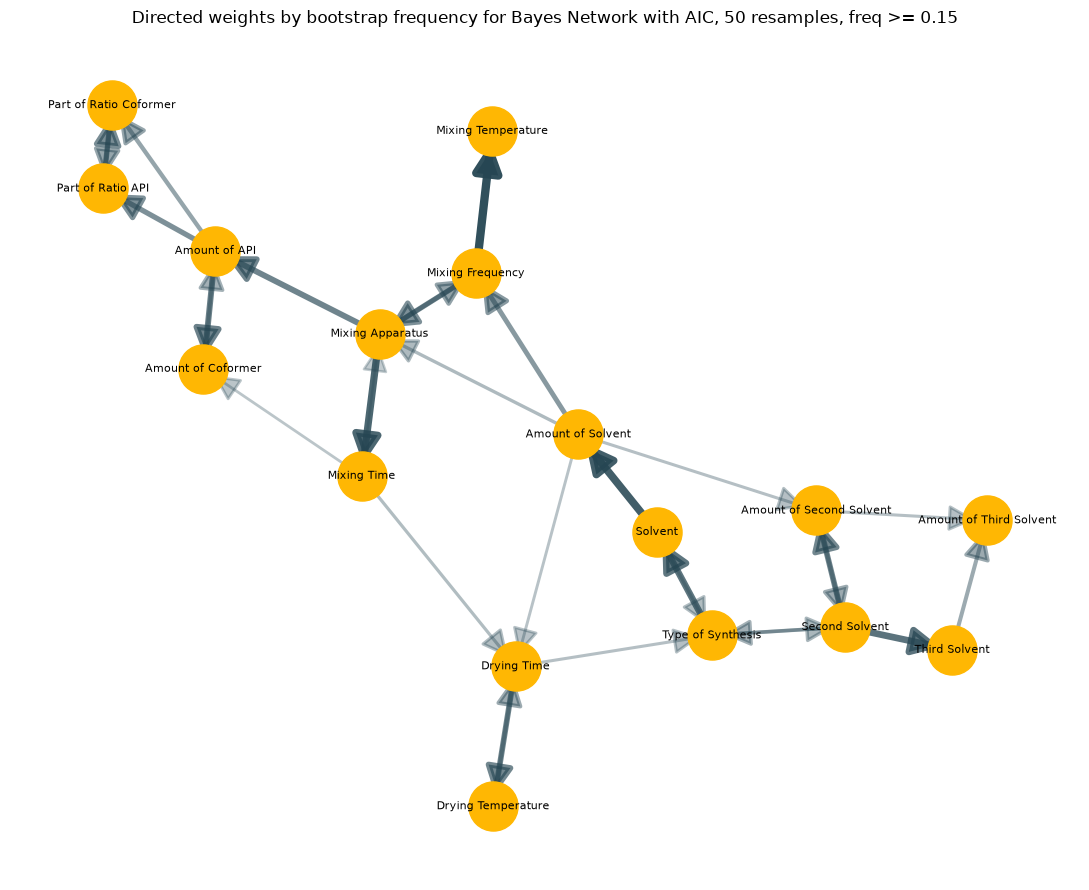

In [ ]:
plot_bootstrap_digraph(
    aic_edges_table_directed[aic_edges_table_directed["frequency"] >= 0.15],
    random_state_addition=5,
    title=f"Directed weights by bootstrap frequency for Bayes Network with AIC, {N_ITERATIONS_AIC} resamples, freq >= 0.15",
)